## Import Required Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('/Users/kundanrathod1310/Documents/data_science/machine_learning/data_set/medical_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Basic Info of Data

In [4]:
df.shape

(2772, 7)

In [5]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df['sex'].value_counts(normalize=True)*100

sex
male      50.721501
female    49.278499
Name: proportion, dtype: float64

In [10]:
df['smoker'].value_counts(normalize=True)*100

smoker
no     79.65368
yes    20.34632
Name: proportion, dtype: float64

In [11]:
df[df['sex']=='male'].groupby('smoker').size()

smoker
no     1074
yes     332
dtype: int64

In [12]:
df[df['sex']=='female'].groupby('smoker').size()

smoker
no     1134
yes     232
dtype: int64

In [13]:
df['region'].value_counts(normalize=True)*100

region
southeast    27.633478
southwest    24.675325
northwest    23.953824
northeast    23.737374
Name: proportion, dtype: float64

In [14]:
df['children'].value_counts(normalize=True)*100

children
0    42.784993
1    24.242424
2    17.893218
3    11.688312
4     1.875902
5     1.515152
Name: proportion, dtype: float64

## Split Data into Training data and Testing data

In [15]:
X = df.drop(['charges'],axis = 1)
y = df['charges']

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2217, 6)
(555, 6)
(2217,)
(555,)


## EDA

<Axes: xlabel='age', ylabel='Count'>

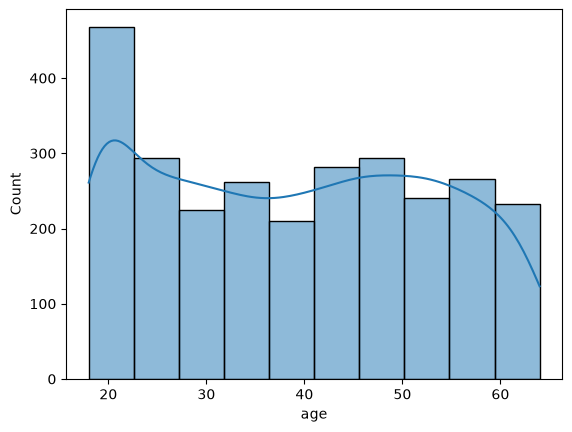

In [18]:
sns.histplot(X['age'],bins=10,kde=True)

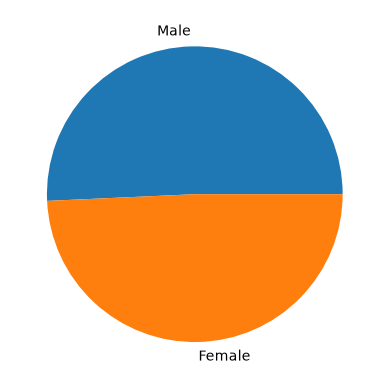

In [19]:
count = X['sex'].value_counts()
lable = ['Male','Female']
plt.pie(count,labels=lable)

<Axes: xlabel='sex', ylabel='count'>

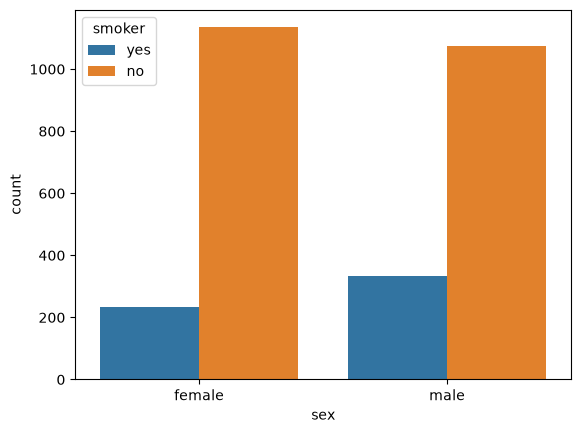

In [20]:
sns.countplot(data = X , x = 'sex' , hue = 'smoker')

<Axes: xlabel='age', ylabel='Count'>

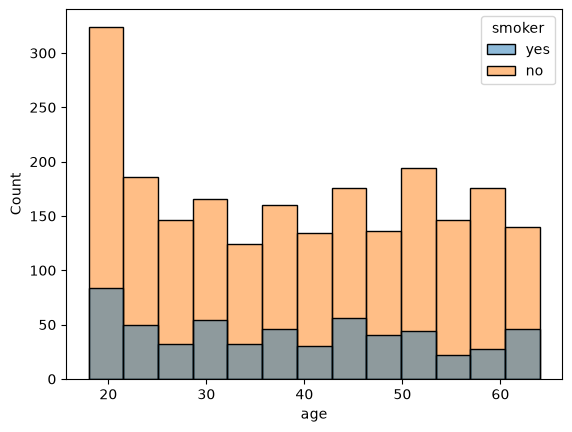

In [21]:
sns.histplot(data = X , x = 'age' , hue = 'smoker')

<Axes: xlabel='age', ylabel='bmi'>

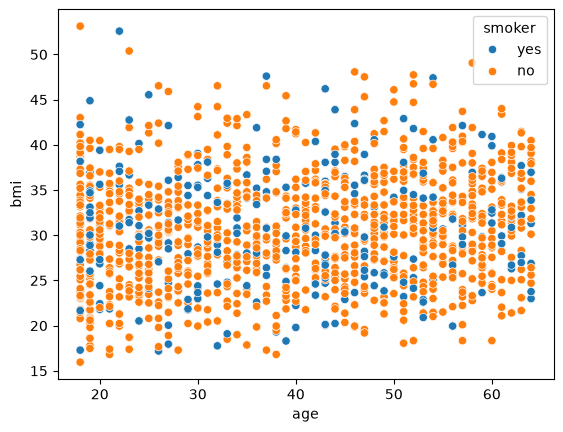

In [22]:
sns.scatterplot(data = X, x = 'age', y = 'bmi', hue = 'smoker')

<Axes: xlabel='children', ylabel='charges'>

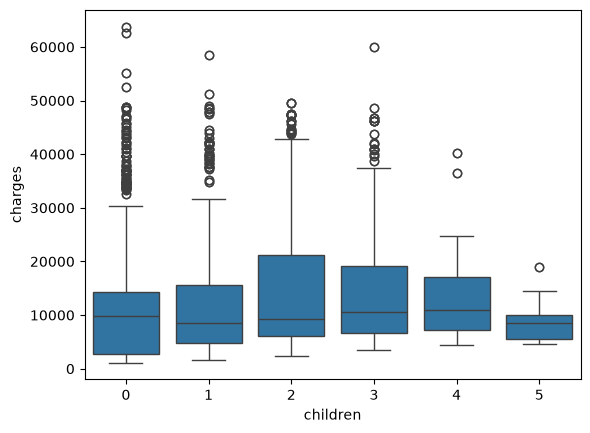

In [23]:
sns.boxplot(data = X , x = 'children' , y = y)

<Axes: >

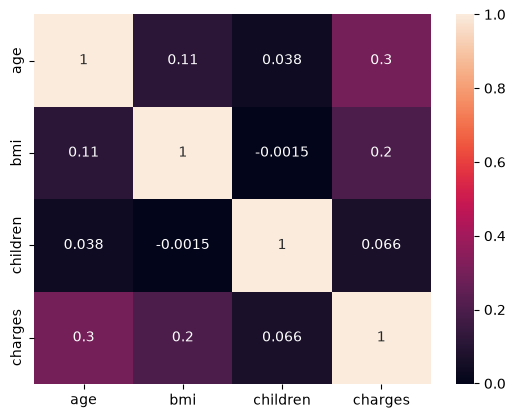

In [24]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr , annot = True)

## Handling Categorical Features

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

In [26]:
trans = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output = False),['sex','region']),
    ('or',OrdinalEncoder(categories=[['yes','no']]),['smoker'])
],remainder='passthrough')

## Create Object of Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr = LinearRegression()

## Create Pipeline of Model

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
pipe = Pipeline(steps=[
    ('transformer',trans),
    ('Linear Regression',lr)
])

## Train Linear Regression Model & Predict X_test

In [31]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('Linear Regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('or', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [32]:
y_pred = pipe.predict(X_test)

## Model Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,R2 Score

In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [34]:
print('MAE : ',mean_absolute_error(y_test,y_pred))
print('MSE : ',mean_squared_error(y_test,y_pred))
print('RMSE : ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2_Score : ',r2_score(y_test,y_pred))

MAE :  4160.24797476299
MSE :  39933194.54805149
RMSE :  6319.271678607551
R2_Score :  0.7398166177564298


## Create Model .pkl File

In [35]:
import joblib

In [36]:
joblib.dump(pipe,'regression_model.pkl')

['regression_model.pkl']